# Paper Figures

Synthesis of the paper-relevant parts of the three analysis notebooks
(`stream_analysis.ipynb`, `spmv_analysis.ipynb`, `krylov_analysis.ipynb`).

This notebook regenerates the 11 figures used in the current paper draft
(`Paper/figures/generated/`) plus the data preparation that precedes them and
the top-10% configuration table. Figures are written to `images/`.

Notes:
* All figures share the style from `common_style.py` (`cs.apply_style()`).
* Line plots use a common legend helper and matching marker/line sizes.
* Variables are section-prefixed (`stream_*`, `spmv_*`, `kry_*`) so that any
  cell can be re-run safely without being overwritten by a later section.
* The per-iteration (intra-binary) data-validity analysis is omitted.
* The Krylov `MB` column is omitted: no paper figure uses it and the
  `matrices/binary_spmc` directory is not tracked.


# 0. Setup

In [2]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

import common_style as cs

cs.apply_style()

MODE_PALETTE = cs.MODE_PALETTE
MODE_PALETTE_2 = cs.MODE_PALETTE_2

os.makedirs("images", exist_ok=True)


In [3]:
# ── File paths ───────────────────────────────────────────────────────────────
matrix_path    = "../matrices/spmv"
spmv_results   = "../outputs/spmv"
krylov_results = "../outputs/krylov"

SPMV_FOLDERS = {
    "Native":            spmv_results + "/native/",
    "SME":               spmv_results + "/sme/",
    "SME+SEV":           spmv_results + "/sev/",
    "Native_interleave": spmv_results + "/native_interleave/",
    "SME_interleave":    spmv_results + "/sme_interleave/",
    "SME+SEV_interleave": spmv_results + "/sev_interleave/",
}

KRYLOV_FOLDERS = {
    "Native":             krylov_results + "/native/",
    "SME":                krylov_results + "/sme/",
    "SME+SEV":            krylov_results + "/sev/",
    "Native_interleave":  krylov_results + "/native_interleave/",
    "SME_interleave":     krylov_results + "/sme_interleave/",
    "SME+SEV_interleave": krylov_results + "/sev_interleave/",
}


# 1. Shared helpers

In [4]:
def iqr_filter(df, cols, k=1.5):
    """Keep only rows within k*IQR of the median for each column in `cols`."""
    mask = pd.Series(True, index=df.index)
    for c in cols:
        q1, q3 = df[c].quantile([0.25, 0.75])
        iqr    = q3 - q1
        mask  &= df[c].between(q1 - k * iqr, q3 + k * iqr)
    return df[mask]


In [5]:
def get_mb(n, randomness):
    """Return the file size in MiB for the matrix with given N and randomness."""
    r_str  = str(randomness).replace('.', '-')
    f_path = os.path.join(matrix_path, f"{r_str}_N{int(n)}.bin")
    try:
        return round(os.path.getsize(f_path) / (1024 ** 2))
    except FileNotFoundError:
        return None


In [41]:
def plot_metric_by_dimensions(
    input_df,
    metric,
    y_axis_name,
    top=False,
    figname=None,
    palette=None,
    legend=True,
    top_metrics=("MB", "Cores"),
    bottom_metrics=("Randomness", "VM_NUMA", "Process_NUMA"),
    size=(cs.COLW, 2.6),
    anchor=1.0,
    errorbar=("ci", 95),
    hue_order=None,
    single_row=False,
):
    dim_orders = {
        "VM_NUMA": ["strict", "interleave"],
        "Process_NUMA": ["strict", "interleave"],
        "L3_fit": [False, True],
    }

    has_bottom = bool(bottom_metrics)

    if single_row:
        all_metrics = list(top_metrics) + list(bottom_metrics)

        width_ratios = [
            len(dim_orders.get(m, input_df[m].unique()))
            for m in all_metrics
        ]

        fig = plt.figure(figsize=size, constrained_layout=True)
        gs = fig.add_gridspec(
            1,
            len(all_metrics),
            width_ratios=width_ratios,
        )

        axes = {
            m: fig.add_subplot(gs[0, i])
            for i, m in enumerate(all_metrics)
        }

    elif has_bottom:
        n_top, n_bot = len(top_metrics), len(bottom_metrics)
        ncols = n_top * n_bot

        fig = plt.figure(figsize=size, constrained_layout=True)
        gs = fig.add_gridspec(2, ncols, height_ratios=[1, 1])

        top_w = ncols // n_top
        bot_w = ncols // n_bot

        axes = {
            **{
                m: fig.add_subplot(
                    gs[0, i * top_w:(i + 1) * top_w]
                )
                for i, m in enumerate(top_metrics)
            },
            **{
                m: fig.add_subplot(
                    gs[1, i * bot_w:(i + 1) * bot_w]
                )
                for i, m in enumerate(bottom_metrics)
            },
        }

    else:
        n_top = len(top_metrics)

        fig = plt.figure(figsize=size, constrained_layout=True)
        gs = fig.add_gridspec(1, n_top)

        axes = {
            m: fig.add_subplot(gs[0, i])
            for i, m in enumerate(top_metrics)
        }

    fig.supylabel(y_axis_name, fontsize=8)

    title_map = {
        "MB": "Matrix Size (MiB)",
        "Cores": "Cores",
        "Randomness": "Randomness",
        "VM_NUMA": "VM NUMA",
        "Process_NUMA": "Process NUMA",
        "L3_fit": "L3 Cache Fit",
    }

    ordered_dims = list(top_metrics) + (
        list(bottom_metrics) if has_bottom else []
    )

    legend_handles, legend_labels = None, None

    for a in ordered_dims:
        ax = axes[a]

        sns.barplot(
            data=input_df,
            x=a,
            y=metric,
            hue="Mode",
            hue_order=hue_order,
            order=dim_orders.get(a, None),
            edgecolor="black",
            linewidth=0.6,
            ax=ax,
            palette=palette,
            errorbar=errorbar,
        )
        ax.set_ylim(bottom=0)

        if legend_handles is None:
            legend_handles, legend_labels = ax.get_legend_handles_labels()

        if ax.get_legend() is not None:
            cs.remove_legend(ax)

        ax.set_title(
            title_map.get(a, a.replace("_", " ")),
            fontsize=8,
        )

        ax.set_ylabel("")
        ax.set_xlabel("")

        tick_fontsize = 6 if a in ("VM_NUMA", "Process_NUMA") else 8

        ax.tick_params(
            axis="x",
            labelsize=tick_fontsize,
        )
        ax.tick_params(axis="y")

        if top:
            ax.xaxis.set_ticks_position("top")
            ax.xaxis.set_label_position("top")
        else:
            ax.xaxis.set_ticks_position("bottom")
            ax.xaxis.set_label_position("bottom")

    if legend and legend_handles is not None:
        fig.legend(
            legend_handles,
            legend_labels,
            loc="lower center",
            ncol=len(legend_labels),
            bbox_to_anchor=(0.5, anchor),
            frameon=False,
        )

    if figname:
        fig.savefig(f"images/{figname}")

    for dim in ordered_dims:
        print(f"→ {dim.replace('_', ' ')}:")

        summary = (
            input_df.groupby([dim, "Mode"])[metric]
            .mean()
            .round(2)
            .reset_index()
        )

        summary_pivot = summary.pivot(
            index=dim,
            columns="Mode",
            values=metric,
        )

        if dim in dim_orders:
            summary_pivot = summary_pivot.reindex(
                dim_orders[dim]
            )

        print(
            summary_pivot.to_string(
                float_format="{:.1f}".format
            )
        )
        print("-" * 60)


# 2. STREAM

`stream_plot.pdf` (paper Figure `fig:stream`).

    Threads      Env Function  BestRate_MBs   AvgTime   MinTime   MaxTime  \
0        48   Native     Copy       61923.3  0.111394  0.111126  0.111702   
1        48   Native    Scale       61896.4  0.111325  0.111174  0.111513   
2        48   Native      Add       70279.8  0.147114  0.146869  0.147658   
3        48   Native    Triad       70507.8  0.146606  0.146394  0.146878   
4        48      SME     Copy       60713.7  0.113554  0.113340  0.113983   
5        48      SME    Scale       60688.5  0.113638  0.113387  0.114981   
6        48      SME      Add       68625.7  0.150852  0.150409  0.151225   
7        48      SME    Triad       68761.5  0.150396  0.150112  0.150735   
8        48  SME+SEV     Copy       60670.3  0.113809  0.113421  0.117716   
9        48  SME+SEV    Scale       60715.2  0.113842  0.113337  0.114319   
10       48  SME+SEV      Add       68578.3  0.151182  0.150513  0.152193   
11       48  SME+SEV    Triad       68751.3  0.150509  0.150134  0.150896   

Env
Native     0.000000
SME        2.183803
SME+SEV    2.211018
Name: Overhead_pct, dtype: float64

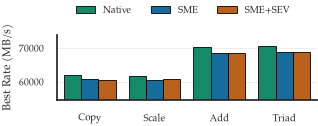

In [7]:
stream_df = pd.read_csv("../outputs/stream/results.csv")

fig, ax = plt.subplots(figsize=(cs.COLW, 0.85))
sns.barplot(
    data=stream_df, x="Function", y="BestRate_MBs", hue="Env",
    hue_order=cs.MODE_ORDER, palette=cs.MODE_PALETTE,
    edgecolor="black", linewidth=0.6, ax=ax,
)
ax.set_ylim(stream_df["BestRate_MBs"].min() * 0.9)
ax.set_ylabel("Best Rate (MB/s)")
ax.set_xlabel("")
cs.top_legend(fig, ax, ncol=3)
fig.savefig("images/stream_plot.pdf")

stream_native = stream_df[stream_df["Env"] == "Native"].set_index("Function")
stream_df["Overhead_pct"] = stream_df.apply(lambda row: (1 - row["BestRate_MBs"] / stream_native.loc[row["Function"], "BestRate_MBs"]) * 100, axis=1)
print(stream_df)
stream_df.groupby("Env")["Overhead_pct"].mean()


# 3. SpMV

## 3.1 Data preparation

Load per-mode run CSVs, remove per-metric IQR outliers, aggregate to one median
row per configuration, and build the overhead frame used by all SpMV figures.

In [8]:
spmv_results_list = []

for label, path in SPMV_FOLDERS.items():
    f_path = os.path.join(path, 'results.csv')
    if os.path.exists(f_path):
        spmv_run         = pd.read_csv(f_path)
        spmv_run['Mode'] = label.split('_interleave')[0]
        spmv_run['VM_NUMA'] = 'interleave' if 'interleave' in label else 'strict'
        spmv_run['Process_NUMA_Policy'] = spmv_run['Process_NUMA_Policy'].replace({'membind': 'strict'})
        spmv_results_list.append(spmv_run)
        print(f"Loaded {len(spmv_run):>5} rows  ← {label}")

spmv_raw = pd.concat(spmv_results_list, ignore_index=True)
spmv_raw.rename(columns={'Process_NUMA_Policy': 'Process_NUMA'}, inplace=True)
print(f"\nTotal rows: {len(spmv_raw)}")


Loaded  1200 rows  ← Native
Loaded  1200 rows  ← SME
Loaded  1200 rows  ← SME+SEV
Loaded  1200 rows  ← Native_interleave
Loaded  1200 rows  ← SME_interleave
Loaded  1200 rows  ← SME+SEV_interleave

Total rows: 7200


In [9]:
spmv_config_cols_raw = ['Mode', 'Matrix', 'Cores', 'Process_NUMA', 'VM_NUMA', 'Iterations']
spmv_metric_cols_raw = ['IO_Time', 'SpMV_Time', 'Perf_Cycles', 'Perf_Instructions',
                   'Perf_CacheMisses', 'Perf_dTLBMisses']

spmv_config_drop_counts = []

def _spmv_iqr_mark_outliers(group):
    """Replace per-metric outliers (IQR method) with NaN within a config group."""
    group      = group.copy()
    group_drops = 0
    for col in spmv_metric_cols_raw:
        if col not in group.columns:
            continue
        valid_rows    = group[[col]].dropna()
        filtered_rows = iqr_filter(valid_rows, [col])
        outlier_idx   = valid_rows.index.difference(filtered_rows.index)
        group_drops  += len(outlier_idx)
        group.loc[outlier_idx, col] = np.nan
    spmv_config_drop_counts.append(group_drops)
    return group

spmv_clean = (
    spmv_raw.groupby(spmv_config_cols_raw)
    .apply(_spmv_iqr_mark_outliers, include_groups=False)
    .reset_index()
)

total_removed = sum(spmv_config_drop_counts)
total_pts     = len(spmv_raw) * len(spmv_metric_cols_raw)
print(f"Total metric data points:  {total_pts}")
print(f"Outlier data points removed: {total_removed} ({total_removed / total_pts * 100:.2f}%)")


Total metric data points:  43200
Outlier data points removed: 2193 (5.08%)


In [10]:
# Aggregate to one median row per configuration
spmv_df = spmv_clean.groupby(spmv_config_cols_raw)[spmv_metric_cols_raw].median().reset_index()

# Derived columns
spmv_df['N']          = spmv_df['Matrix'].str.extract(r'N(\d+)').astype(int)
r                = spmv_df['Matrix'].str.extract(r'(\d)-(\d)')
spmv_df['Randomness'] = (r[0] + "." + r[1]).astype(float)
spmv_df['MB']         = spmv_df.apply(lambda row: get_mb(row['N'], row['Randomness']), axis=1).astype('Int64')

K_NNZ = 30  # assumed non-zeros per row
# SpMV_Time is the total time for `Iterations` SpMV calls.
spmv_df['SpMV_GFLOPS'] = (2 * K_NNZ * spmv_df['N']) / ((spmv_df['SpMV_Time'] / spmv_df['Iterations']) * 1e9)

L3_SIZE_MB = {1: 32, 8: 32, 24: 96, 48: 192}  # L3 per core-count config
spmv_df['L3_fit']   = spmv_df['MB'] <= spmv_df['Cores'].map(L3_SIZE_MB)
spmv_df['Perf_IPC'] = spmv_df['Perf_Instructions'] / spmv_df['Perf_Cycles']
spmv_df.drop(columns=['N', 'Matrix'], inplace=True)

spmv_config_cols = ['Mode', 'MB', 'Randomness', 'Cores', 'Process_NUMA', 'VM_NUMA', 'L3_fit']
spmv_metric_cols = spmv_metric_cols_raw + ['SpMV_GFLOPS', 'Perf_IPC']

spmv_df.head()


,Mode,Cores,Process_NUMA,VM_NUMA,Iterations,IO_Time,SpMV_Time,Perf_Cycles,Perf_Instructions,Perf_CacheMisses,Perf_dTLBMisses,Randomness,MB,SpMV_GFLOPS,L3_fit,Perf_IPC
0,Native,1,interleave,interleave,369,0.081600,9.948239,3.613565e+10,1.993093e+11,3298979.0,364995.0,0.0,500,3.205531,False,5.515586
1,Native,1,interleave,strict,369,0.082036,9.993071,3.630054e+10,1.993093e+11,3276049.0,395074.5,0.0,500,3.191150,False,5.490532
2,Native,1,strict,interleave,369,0.081796,9.945920,3.612669e+10,1.993093e+11,3276159.0,345223.0,0.0,500,3.206279,False,5.516955
3,Native,1,strict,strict,369,0.081642,9.991050,3.630536e+10,1.993093e+11,3250803.0,344848.0,0.0,500,3.191796,False,5.489804
4,Native,8,interleave,interleave,713,0.081595,10.267954,2.962630e+11,3.852660e+11,16812143.0,16328.0,0.0,500,6.001026,False,1.300419


In [11]:
# Build overhead DataFrame: percentage overhead vs. Native for each metric.
# Sign convention: positive overhead = worse performance.
#   - time-like metrics (higher = worse):   100 * (m / native - 1)
#   - throughput metrics (higher = better): 100 * (1 - m / native)
spmv_merge_cols = [c for c in spmv_config_cols if c != 'Mode']

spmv_native = spmv_df[spmv_df['Mode'] == 'Native'].copy()
spmv_other  = spmv_df[spmv_df['Mode'] != 'Native'].copy()

spmv_overhead = spmv_other.merge(spmv_native, on=spmv_merge_cols, suffixes=('', '_native'))

spmv_throughput_metrics = {"SpMV_GFLOPS", "Perf_IPC"}

for m in spmv_metric_cols:
    native_col = f"{m}_native"
    if m in spmv_throughput_metrics:
        spmv_overhead[f"{m}_pct"] = np.where(
            spmv_overhead[native_col] != 0,
            (1 - spmv_overhead[m] / spmv_overhead[native_col]) * 100,
            np.nan
        )
    else:
        spmv_overhead[f"{m}_pct"] = np.where(
            spmv_overhead[native_col] != 0,
            (spmv_overhead[m] / spmv_overhead[native_col] - 1) * 100,
            np.nan
        )


## 3.2 SpMV figures

In paper order: absolute GFLOPS (`fig:absolute_gflops`), VM-NUMA heatmap
(`fig:numa_change`), GFLOPS overhead distribution (`fig:gflops_overhead_distribution`),
overhead per dimension (`fig:overhead_per_dim`), cache misses (`fig:cache_miss`),
dTLB misses (`fig:dtlb_miss`), dTLB–GFLOPS correlation (`fig:dtlb_corr`), and
I/O time (`fig:io`).

→ MB:
Mode  Native
MB          
10      40.0
70      42.8
150     36.9
500     14.6
3000     7.9
------------------------------------------------------------
→ Cores:
Mode   Native
Cores        
1         2.4
8        10.0
24       34.9
48       66.3
------------------------------------------------------------
→ Randomness:
Mode        Native
Randomness        
0.0           34.6
1.0           22.2
------------------------------------------------------------
→ VM NUMA:
Mode        Native
VM_NUMA           
strict        27.2
interleave    29.7
------------------------------------------------------------
→ Process NUMA:
Mode          Native
Process_NUMA        
strict          28.4
interleave      28.4
------------------------------------------------------------


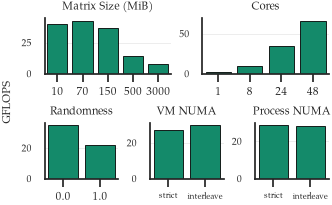

In [42]:
plot_metric_by_dimensions(
    spmv_df[spmv_df["Mode"] == "Native"], 'SpMV_GFLOPS', 'GFLOPS',
    top=False, figname='absolute_gflops_per_dim.pdf',
    palette=MODE_PALETTE, legend=False, errorbar=None,
    size=(cs.COLW, 2.1), hue_order=["Native"],
)

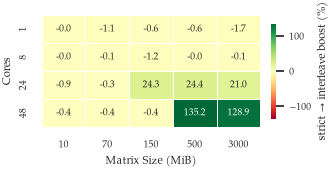

In [13]:
# VM_NUMA boost: interleave vs strict (Native only)
heat_df = (
	spmv_df.pivot_table(
		index=["Mode", "Cores", "MB", "Randomness", "Process_NUMA"],
		columns="VM_NUMA",
		values="SpMV_GFLOPS",
		aggfunc="mean"
	)
	.dropna(subset=["interleave", "strict"])
	.reset_index()
)

heat_df["Boost_pct"] = (heat_df["interleave"] - heat_df["strict"]) / heat_df["strict"] * 100

mode_cell = (
	heat_df.groupby(["MB", "Cores", "Mode"], as_index=False)["Boost_pct"]
	.mean()
)
mode_cell = mode_cell[mode_cell["Mode"] == "Native"].copy()

vabs = mode_cell["Boost_pct"].abs().max()

fig, ax = plt.subplots(figsize=(cs.COLW, 1.6), constrained_layout=True)

p_mode = (
	mode_cell.pivot(index="Cores", columns="MB", values="Boost_pct")
	.sort_index()
)
p_mode = p_mode.reindex(sorted(p_mode.columns), axis=1)

sns.heatmap(
	p_mode,
	ax=ax,
	cmap="RdYlGn",
	center=0,
	vmin=-vabs,
	vmax=vabs,
	annot=True,
	fmt=".1f",
	annot_kws={"size": 7},
	linewidths=0.4,
	linecolor="white",
	cbar=True,
	cbar_kws={"label": "strict → interleave boost (%)", "shrink": 0.85}
)

ax.set_xlabel("Matrix Size (MiB)")
ax.set_ylabel("Cores")

fig.savefig("images/vm_numa_boost_heatmap_native_only.pdf")
plt.show()


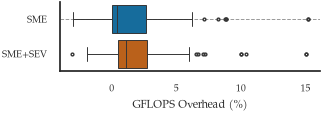

In [14]:
fig, ax = plt.subplots(figsize=(cs.COLW, 0.9))
sns.boxplot(
    data=spmv_overhead, x='SpMV_GFLOPS_pct', y='Mode', hue='Mode',
    hue_order=cs.MODE_ORDER_2, palette=MODE_PALETTE_2, ax=ax,
    fliersize=2, linewidth=0.7,
)
cs.zero_line(ax)
ax.set_xlabel('GFLOPS Overhead (%)')
ax.set_ylabel('')
cs.remove_legend(ax)
fig.savefig('images/GFLOPS_Overhead_Distribution.pdf')
plt.show()


→ MB:
Mode  SME  SME+SEV
MB                
10    0.9      1.0
70    0.7      1.2
150   1.3      1.9
500   2.3      2.4
3000  2.9      3.0
------------------------------------------------------------
→ Cores:
Mode   SME  SME+SEV
Cores              
1      2.9      3.1
8      0.4      0.2
24     1.6      1.9
48     1.6      2.3
------------------------------------------------------------
→ Randomness:
Mode        SME  SME+SEV
Randomness              
0.0         1.0      1.2
1.0         2.2      2.6
------------------------------------------------------------
→ L3 fit:
Mode    SME  SME+SEV
L3_fit              
False   2.1      2.2
True    0.8      1.3
------------------------------------------------------------
→ VM NUMA:
Mode        SME  SME+SEV
VM_NUMA                 
strict      2.4      1.9
interleave  0.9      1.8
------------------------------------------------------------
→ Process NUMA:
Mode          SME  SME+SEV
Process_NUMA              
strict        1.6      1.9
interleave 

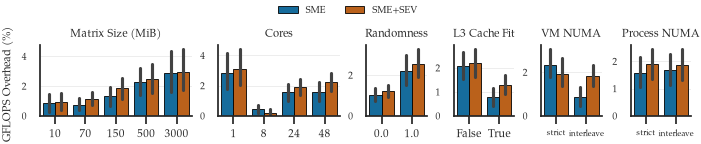

In [44]:
plot_metric_by_dimensions(
    spmv_overhead,
    'SpMV_GFLOPS_pct',
    'GFLOPS Overhead (%)',
    top=False,
    figname='overhead_per_dim.pdf',
    palette=MODE_PALETTE_2,
    legend=True,
    bottom_metrics=('Randomness', 'L3_fit', 'VM_NUMA', 'Process_NUMA'),
    size=(cs.TEXTW, 1.2),
    hue_order=cs.MODE_ORDER_2,
    single_row=True,
)

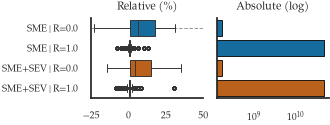

Median Relative Cache Misses (%):
Mode
SME        0.71
SME+SEV    1.03
IQR Relative Cache Misses (%):
Mode
SME        6.77
SME+SEV    4.61


In [34]:
cmiss_df = spmv_overhead.copy()
cmiss_df["Mode_Randomness"] = cmiss_df["Mode"] + " | R=" + cmiss_df["Randomness"].astype(str)

cmiss_df = cmiss_df.merge(
    spmv_df[["Mode", "Randomness", "Perf_CacheMisses"]],
    on=["Mode", "Randomness"],
    how="left"
)

fig, axes = plt.subplots(
    1, 2,
    figsize=(cs.COLW, 1.3),
    constrained_layout=True,
    sharey=True
)

sns.boxplot(
    data=cmiss_df,
    x="Perf_CacheMisses_pct",
    y="Mode_Randomness",
    hue="Mode",
    hue_order=cs.MODE_ORDER_2,
    palette=MODE_PALETTE_2,
    ax=axes[0],
    fliersize=2,
    linewidth=0.7,
)
axes[0].set_title("Relative (%)", fontsize=8)
axes[0].set_xlabel("")
axes[0].set_ylabel("")
axes[0].set_xlim(-25, 50)
cs.zero_line(axes[0])

sns.barplot(
    data=cmiss_df,
    x="Perf_CacheMisses_x",
    y="Mode_Randomness",
    hue="Mode",
    hue_order=cs.MODE_ORDER_2,
    palette=MODE_PALETTE_2,
    ax=axes[1],
    errorbar=None,
    edgecolor="black",
    linewidth=0.6,
)
axes[1].set_xscale("log")
axes[1].set_title("Absolute (log)", fontsize=8)
axes[1].set_ylabel("")
axes[1].set_xlabel("")

# Remove all legends
for ax in axes:
    legend = ax.get_legend()
    if legend is not None:
        legend.remove()

fig.savefig("images/CacheMiss_Relative_vs_Absolute.pdf")
plt.show()

print("Median Relative Cache Misses (%):")
print(
    spmv_overhead.groupby("Mode")["Perf_CacheMisses_pct"]
    .median()
    .round(2)
    .to_string()
)

print("IQR Relative Cache Misses (%):")
iqr = spmv_overhead.groupby("Mode")["Perf_CacheMisses_pct"].agg(
    lambda x: x.quantile(0.75) - x.quantile(0.25)
)
print(iqr.round(2).to_string())

            median
Mode              
SME      -1.226530
SME+SEV  26.696486


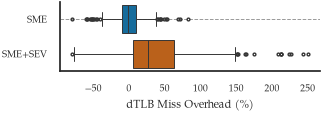

In [17]:
fig, ax = plt.subplots(figsize=(cs.COLW, 0.9))
sns.boxplot(
    data=spmv_overhead,
    x="Perf_dTLBMisses_pct",
    y="Mode",
    hue="Mode",
    hue_order=cs.MODE_ORDER_2,
    palette=MODE_PALETTE_2,
    ax=ax,
    fliersize=2,
    linewidth=0.7,
)
cs.zero_line(ax)
ax.set_xlabel("dTLB Miss Overhead (%)")
ax.set_ylabel("")
cs.remove_legend(ax)
fig.savefig("images/dTLB_Miss_Overhead_Distribution.pdf")

print(spmv_overhead.groupby("Mode")["Perf_dTLBMisses_pct"].aggregate(['median']))


Pearson : 0.21548105913543103
Spearman: 0.21722386019322387


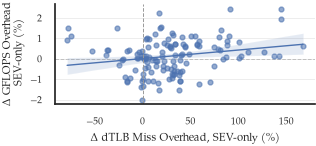

In [18]:
pivot = spmv_overhead.pivot_table(
    index=["MB", "Cores", "VM_NUMA", "Process_NUMA", "Randomness"],
    columns="Mode",
    values=["SpMV_GFLOPS_pct", "Perf_dTLBMisses_pct"]
)

pivot.columns = ["_".join(col) for col in pivot.columns]

pivot["GFLOPS_diff"] = ( pivot["SpMV_GFLOPS_pct_SME+SEV"] - pivot["SpMV_GFLOPS_pct_SME"])
pivot["dTLB_diff"] = ( pivot["Perf_dTLBMisses_pct_SME+SEV"] - pivot["Perf_dTLBMisses_pct_SME"])

corr_df = pivot[["GFLOPS_diff", "dTLB_diff"]].dropna().copy()
corr_iqr = iqr_filter(corr_df, ["GFLOPS_diff", "dTLB_diff"])

print("Pearson :", corr_iqr["GFLOPS_diff"].corr(corr_iqr["dTLB_diff"], method="pearson"))
print("Spearman:", corr_iqr["GFLOPS_diff"].corr(corr_iqr["dTLB_diff"], method="spearman"))

fig, ax = plt.subplots(figsize=(cs.COLW, 1.3))
sns.regplot(
    data=corr_iqr, x="dTLB_diff", y="GFLOPS_diff", ax=ax,
    scatter_kws={"s": 12, "alpha": 0.6}, line_kws={"lw": 1},
)
cs.zero_line(ax)
ax.axvline(0, color="#999999", linewidth=0.7, linestyle="--")
ax.set_xlabel("Δ dTLB Miss Overhead, SEV-only (%)")
ax.set_ylabel("Δ GFLOPS Overhead\n SEV-only (%)")
fig.savefig("images/gflops_dtlb_correlation.pdf")
plt.show()


Mode     MB  
SME      10       3.762282
         70       6.541224
         150      7.040207
         500      7.128418
         3000     8.245188
SME+SEV  10       4.113318
         70       7.937879
         150      8.795880
         500      9.552155
         3000    10.576922
Name: IO_Time_pct, dtype: float64

Average absolute deviation between randomness across configurations: 1.135%


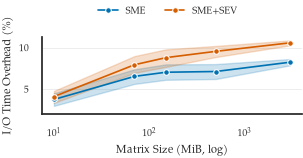

In [30]:
fig, ax = plt.subplots(figsize=(cs.COLW, 1.0))
sns.lineplot(
    data=spmv_overhead, x="MB", y="IO_Time_pct", marker="o", hue="Mode",
    hue_order=cs.MODE_ORDER_2, palette=MODE_PALETTE_2, ax=ax,
    errorbar=("ci", 95), markersize=4, linewidth=1.2,
)
ax.set_xscale("log")
ax.set_ylim(2)
cs.zero_line(ax)
ax.set_xlabel("Matrix Size (MiB, log)")
ax.set_ylabel("I/O Time Overhead (%)")
cs.top_legend(fig, ax, ncol=2)
fig.savefig("images/IO_Time_Overhead_by_MB.pdf")
print(spmv_overhead.groupby(["Mode", "MB"])["IO_Time_pct"].mean())
cfg_cols = ["Mode", "MB", "Cores", "Process_NUMA", "VM_NUMA"]

io_rand_cmp = (
	spmv_overhead
	.pivot_table(
		index=cfg_cols,
		columns="Randomness",
		values="IO_Time_pct",
		aggfunc="mean"
	)
	.dropna(subset=[0.0, 1.0])
	.reset_index()
)

io_rand_cmp["IO_Time_Deviation_pct"] = io_rand_cmp[1.0] - io_rand_cmp[0.0]
io_rand_cmp["Abs_IO_Time_Deviation_pct"] = io_rand_cmp["IO_Time_Deviation_pct"].abs()

print(f"\nAverage absolute deviation between randomness across configurations: {io_rand_cmp['Abs_IO_Time_Deviation_pct'].mean():.3f}%")


## 3.3 Worst configurations (Table 1)

In [20]:
def top_10_percent_per_mode(spmv_df, value_col):
    return spmv_df[
        spmv_df.groupby("Mode")[value_col]
          .transform(lambda x: x.rank(method="first", ascending=False)
                               <= int(len(x) * 0.1))
    ]

cutoffs = spmv_overhead.groupby("Mode")["SpMV_GFLOPS_pct"].apply(
    lambda x: x.nlargest(int(len(x) * 0.1)).min()
)

print(cutoffs)

top_configs = top_10_percent_per_mode(spmv_overhead, "SpMV_GFLOPS_pct")

result_df = (
    top_configs
    .melt(id_vars=["Mode"], value_vars=spmv_config_cols,
          var_name="Metric", value_name="Value")
    .groupby(["Mode", "Metric", "Value"])
    .size()
    .reset_index(name="Count")
)

result_df["Representation"] = (
    result_df.groupby(["Mode", "Metric"])["Count"]
    .transform(lambda x: 100 * x / x.sum())
)

result_df = result_df.sort_values(
    ["Mode", "Metric", "Representation"],
    ascending=[True, True, False]
)

n_levels = spmv_overhead[spmv_config_cols].nunique()

result_df["Expected"] = result_df["Metric"].map(lambda m: 1 / n_levels[m])

result_df["Lift"] = (
    result_df["Representation"] / 100
) / result_df["Expected"]

result_df


Mode
SME        4.723854
SME+SEV    4.960052
Name: SpMV_GFLOPS_pct, dtype: float64


,Mode,Metric,Value,Count,Representation,Expected,Lift
0,SME,Cores,1.0,10,62.50,0.25,2.5000
1,SME,Cores,24,3,18.75,0.25,0.7500
2,SME,Cores,48,3,18.75,0.25,0.7500
3,SME,L3_fit,0.0,14,87.50,0.50,1.7500
4,SME,L3_fit,1.0,2,12.50,0.50,0.2500
9,SME,MB,3000,6,37.50,0.20,1.8750
8,SME,MB,500,5,31.25,0.20,1.5625
7,SME,MB,150,3,18.75,0.20,0.9375
5,SME,MB,10,1,6.25,0.20,0.3125
6,SME,MB,70,1,6.25,0.20,0.3125


# 4. Krylov

## 4.1 Data preparation

In [21]:
kry_results_list = []

for label, path in KRYLOV_FOLDERS.items():
    f_path = os.path.join(path, "results.csv")
    if os.path.exists(f_path):
        kry_run            = pd.read_csv(f_path)
        kry_run["Mode"]    = label.split("_interleave")[0]
        kry_run["VM_NUMA"] = "interleave" if "interleave" in label else "strict"
        kry_run['Process_NUMA_Policy'] = kry_run['Process_NUMA_Policy'].replace({'membind': 'strict'})
        kry_results_list.append(kry_run)
        print(f"Loaded {len(kry_run):>5} rows  ← {label}")

kry_raw = pd.concat(kry_results_list, ignore_index=True)
kry_raw.rename(columns={"Process_NUMA_Policy": "Process_NUMA"}, inplace=True)
print(f"\nTotal rows: {len(kry_raw)}")


Loaded  2400 rows  ← Native
Loaded  2400 rows  ← SME
Loaded  2400 rows  ← SME+SEV
Loaded  2400 rows  ← Native_interleave
Loaded  2400 rows  ← SME_interleave
Loaded  2400 rows  ← SME+SEV_interleave

Total rows: 14400


In [22]:
kry_config_cols_raw = ["Mode", "Matrix", "Cores", "Process_NUMA", "VM_NUMA",
                   "Algo", "Arg1", "Arg2", "Arg3", "N_Ops"]
kry_metric_cols_raw = ["SpMV_Time", "Mgmt_Time", "Perf_Cycles", "Perf_Instructions",
                   "Perf_CacheMisses", "Perf_dTLBMisses"]

kry_config_drop_counts = []

def _kry_iqr_mark_outliers(group):
    """Replace per-metric outliers (IQR method) with NaN within a config group."""
    group       = group.copy()
    group_drops = 0
    for col in kry_metric_cols_raw:
        if col not in group.columns:
            continue
        valid_rows    = group[[col]].dropna()
        if valid_rows.empty:
            continue
        filtered_rows = iqr_filter(valid_rows, [col])
        outlier_idx   = valid_rows.index.difference(filtered_rows.index)
        group_drops  += len(outlier_idx)
        group.loc[outlier_idx, col] = np.nan
    kry_config_drop_counts.append(group_drops)
    return group

kry_clean = (
    kry_raw.groupby(kry_config_cols_raw)
    .apply(_kry_iqr_mark_outliers, include_groups=False)
    .reset_index()
)

total_removed = sum(kry_config_drop_counts)
total_pts     = len(kry_raw) * len(kry_metric_cols_raw)
print(f"Total metric data points:    {total_pts}")
print(f"Outlier data points removed: {total_removed} ({total_removed / total_pts * 100:.2f}%)")


Total metric data points:    86400
Outlier data points removed: 2608 (3.02%)


In [23]:
# Aggregate to one median row per configuration, then derive extra columns
kry_df = kry_clean.groupby(kry_config_cols_raw)[kry_metric_cols_raw].median().reset_index()

# 'bicgstab' contains 'cg' but is *not* symmetric — explicit check required
kry_df["Symmetric"]   = kry_df["Algo"].apply(lambda x: ("cg" in x or "lanczos" in x) and "bicg" not in x)
kry_df["Matrix"]      = kry_df["Matrix"].str.replace(".bin", "", regex=False)
kry_df["Perf_IPC"]    = kry_df["Perf_Instructions"] / kry_df["Perf_Cycles"]
kry_df["Total_Time"]  = kry_df["SpMV_Time"] + kry_df["Mgmt_Time"]
kry_df["Time_per_op"] = kry_df["Total_Time"] / kry_df["N_Ops"]
kry_df["SpMV_Ratio"]  = kry_df["SpMV_Time"] / kry_df["Total_Time"]

kry_metric_cols = kry_metric_cols_raw + ["Perf_IPC", "Time_per_op"]

kry_df.head()


,Mode,Matrix,Cores,Process_NUMA,VM_NUMA,Algo,Arg1,Arg2,Arg3,N_Ops,...,Mgmt_Time,Perf_Cycles,Perf_Instructions,Perf_CacheMisses,Perf_dTLBMisses,Symmetric,Perf_IPC,Total_Time,Time_per_op,SpMV_Ratio
0,Native,Bump2911,1,interleave,interleave,cg,159,0,0,159,...,1.332634,3.561613e+10,1.536218e+11,58302643.0,533281.0,True,4.313265,9.801176,0.061643,0.864033
1,Native,Bump2911,1,interleave,interleave,lanczos,11,2,10,106,...,3.093740,3.147399e+10,1.198801e+11,37869017.0,257503.0,True,3.808863,8.781362,0.082843,0.647692
2,Native,Bump2911,1,interleave,strict,cg,159,0,0,159,...,1.387741,3.701111e+10,1.536218e+11,58115339.0,516729.0,True,4.150694,10.187805,0.064074,0.863784
3,Native,Bump2911,1,interleave,strict,lanczos,11,2,10,106,...,3.061235,3.208136e+10,1.198801e+11,37515727.0,247792.0,True,3.736755,8.941120,0.084350,0.657623
4,Native,Bump2911,1,strict,interleave,cg,159,0,0,159,...,1.331657,3.557956e+10,1.536218e+11,58030389.0,504352.5,True,4.317698,9.790518,0.061576,0.863985


In [24]:
kry_merge_cols = [c for c in kry_config_cols_raw if c != "Mode"]

kry_native = kry_df[kry_df["Mode"] == "Native"].copy()
kry_other  = kry_df[kry_df["Mode"] != "Native"].copy()

cols_to_keep = kry_merge_cols + kry_metric_cols
kry_overhead  = kry_other.merge(kry_native[cols_to_keep], on=kry_merge_cols, suffixes=("", "_native"))

# Sign convention: positive overhead = worse performance.
#   - time-like metrics (higher = worse):   100 * (m / native - 1)
#   - throughput metrics (higher = better): 100 * (1 - m / native)
kry_throughput_metrics = {"Perf_IPC"}

for m in kry_metric_cols:
    native_col = f"{m}_native"
    if m in kry_throughput_metrics:
        kry_overhead[f"{m}_abs"] = kry_overhead[native_col] - kry_overhead[m]
        kry_overhead[f"{m}_pct"] = np.where(
            kry_overhead[native_col] != 0,
            (1 - kry_overhead[m] / kry_overhead[native_col]) * 100,
            np.nan,
        )
    else:
        kry_overhead[f"{m}_abs"] = kry_overhead[m] - kry_overhead[native_col]
        kry_overhead[f"{m}_pct"] = np.where(
            kry_overhead[native_col] != 0,
            (kry_overhead[m] / kry_overhead[native_col] - 1) * 100,
            np.nan,
        )
    kry_overhead.drop(columns=[native_col, m], inplace=True)


## 4.2 Krylov figures

In paper order: per-matrix/algorithm overhead (`fig:krylov_time_per_op`) and
SpMV share of execution time (`fig:krylov_share`).


Symmetric displayed values (Time_per_op_pct):
Group       cg + SME  cg + SME+SEV  lanczos + SME  lanczos + SME+SEV
Matrix                                                              
dawson5         1.36          1.40           1.25               1.97
G3_circuit      4.55          5.62           4.21               4.66
nd12k           2.52          2.80           2.49               2.72
Hook_1498       2.86          3.21           3.31               4.13

Unsymmetric displayed values (Time_per_op_pct):
Group          bicgstab + SME  bicgstab + SME+SEV  arnoldi + SME  arnoldi + SME+SEV
Matrix                                                                             
e40r0100                 2.13                2.36           1.90               2.32
marine1                  3.03                3.44           3.97               4.39
Freescale1               5.10                5.47           3.95               4.23
RM07R                    3.28                3.57           3.14      

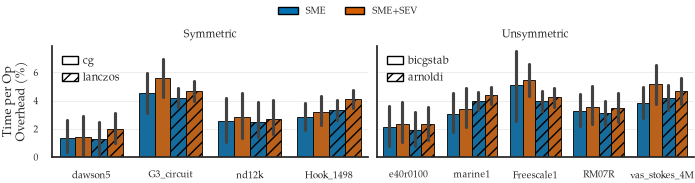

In [25]:
sym_algo_order = ["cg", "lanczos"]
unsym_algo_order = ["bicgstab", "arnoldi"]

algo_patterns = {
    "cg": "",
    "lanczos": "///",
    "bicgstab": "",
    "arnoldi": "///",
}

matrix_order = [
    "dawson5", "G3_circuit", "nd12k", "Hook_1498",
    "Bump_2911", "e40r0100", "marine1", "Freescale1",
    "RM07R", "vas_stokes_4M"
]

modes_palette = MODE_PALETTE_2

fig, axes = plt.subplots(
    1, 2,
    figsize=(cs.TEXTW, 1.6),
    constrained_layout=True,
    sharey=True,
)

for idx, (is_symmetric, title) in enumerate([
    (True, "Symmetric"),
    (False, "Unsymmetric"),
]):
    ax = axes[idx]

    sub = kry_overhead[
        kry_overhead["Symmetric"] == is_symmetric
    ].copy()

    sub["Group"] = sub["Algo"] + " + " + sub["Mode"]

    current_algos = (
        sym_algo_order if is_symmetric
        else unsym_algo_order
    )

    hue_order = [
        f"{algo} + {mode}"
        for algo in current_algos
        for mode in cs.MODE_ORDER_2
    ]

    current_matrices = [
        m for m in matrix_order
        if m in sub["Matrix"].unique()
    ]

    sns.barplot(
        data=sub,
        x="Matrix",
        y="Time_per_op_pct",
        hue="Group",
        hue_order=hue_order,
        order=current_matrices,
        palette=[
            modes_palette[s.split(" + ")[1]]
            for s in hue_order
        ],
        errorbar=("ci", 95),
        edgecolor="black",
        linewidth=0.6,
        ax=ax,
    )

    # Hatch by algorithm
    for container, group_label in zip(ax.containers, hue_order):
        algo_name = group_label.split(" + ")[0].lower()
        pattern = algo_patterns.get(algo_name, "")

        for bar in container:
            bar.set_hatch(pattern)
            bar.set_edgecolor("black")

    ax.set_title(title, fontsize=8)
    ax.set_xlabel("")
    ax.set_ylabel("")

    if idx == 0:
        ax.set_ylabel(
            "Time per Op\nOverhead (%)", fontsize=9
        )

    ax.tick_params(axis="x", labelsize=7)
    ax.tick_params(axis="y", labelsize=7)

    # Horizontal matrix labels
    plt.setp(
        ax.get_xticklabels(),
        rotation=0,
        ha="center",
    )

    cs.remove_legend(ax)

    # Algorithm legend — stacked vertically
    algo_handles = [
        Patch(
            facecolor="white",
            edgecolor="black",
            hatch=algo_patterns.get(a.lower(), ""),
            label=a,
        )
        for a in current_algos
    ]

    ax.legend(
        handles=algo_handles,
        title=None,
        loc="upper left",
        ncol=1,
        fontsize=8,
        frameon=False,
        handlelength=1.5,
        handletextpad=0.4,
    )

    print(
        f"\n{title} displayed values "
        "(Time_per_op_pct):"
    )

    displayed_values = (
        sub.groupby(
            ["Matrix", "Group"]
        )["Time_per_op_pct"]
        .mean()
        .unstack("Group")
        .reindex(
            index=current_matrices,
            columns=hue_order,
        )
    )

    print(
        displayed_values
        .round(2)
        .to_string()
    )

# Mode legend
mode_handles = [
    Patch(
        facecolor=modes_palette[m],
        edgecolor="black",
        label=m,
    )
    for m in cs.MODE_ORDER_2
]

fig.legend(
    handles=mode_handles,
    title=None,
    loc="lower center",
    bbox_to_anchor=(0.5, 1.0),
    ncol=2,
    frameon=False,
)

fig.savefig(
    "images/krylov_overhead_by_algo_matrix.pdf"
)

plt.show()

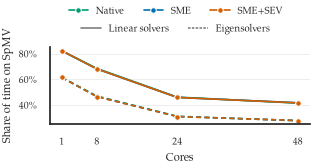


Linear solvers SpMV Ratio (% of total time):
Mode   Native    SME  SME+SEV
Cores                        
1      82.37% 82.33%   82.37%
8      68.60% 68.23%   68.22%
24     46.29% 46.05%   46.04%
48     41.59% 41.89%   41.78%

Eigensolvers SpMV Ratio (% of total time):
Mode   Native    SME  SME+SEV
Cores                        
1      61.59% 61.58%   61.60%
8      47.12% 46.66%   46.62%
24     31.35% 31.16%   31.12%
48     27.86% 28.05%   28.04%


In [29]:
# 1. Prep Data
target_order = [m for m in cs.MODE_ORDER if m in kry_df["Mode"].unique()]
cores = sorted(kry_df["Cores"].unique())

plot_df = kry_df.copy()
plot_df["Group"] = plot_df["Algo"].map({
    "cg": "Linear",
    "bicgstab": "Linear",
    "lanczos": "Eigen",
    "arnoldi": "Eigen",
})

fig, ax = plt.subplots(figsize=(cs.COLW, 1.0))

sns.lineplot(
    data=plot_df,
    x="Cores",
    y="SpMV_Ratio",
    marker="o",
    hue="Mode",
    hue_order=target_order,
    style="Group",
    style_order=["Linear", "Eigen"],
    palette=cs.MODE_PALETTE,
    dashes={"Linear": "", "Eigen": (3, 2)},
    markersize=4,
    linewidth=1.2,
    ax=ax,
    errorbar=None,
)

ax.set_xticks(cores)
ax.yaxis.set_major_formatter(
    plt.matplotlib.ticker.PercentFormatter(1.0)
)
ax.set_xlabel("Cores")
ax.set_ylabel("Share of time on SpMV")

# Get Seaborn legend and keep only Mode entries
handles, labels = ax.get_legend_handles_labels()

mode_handles = [
    handle
    for handle, label in zip(handles, labels)
    if label in target_order
]

mode_labels = [
    label
    for label in labels
    if label in target_order
]

cs.remove_legend(ax)

# Manually create Group legend entries
group_handles = [
    Line2D(
        [0], [0],
        color="grey",
        markersize=4,
        linestyle="-",
        linewidth=1.2,
        label="Linear solvers",
    ),
    Line2D(
        [0], [0],
        color="grey",
        markersize=4,
        linestyle=(0, (1.5, 0.8)),
        linewidth=1.2,
        label="Eigensolvers",
    ),
]

# Separate legends
mode_legend = fig.legend(
    handles=mode_handles,
    labels=mode_labels,
    ncol=len(mode_handles),
    loc="lower center",
    bbox_to_anchor=(0.5, 1.1),
    frameon=False,
)

group_legend = fig.legend(
    handles=group_handles,
    ncol=2,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.92),
    frameon=False,
)

fig.savefig("images/krylov_execution_time_ratio.pdf")
plt.show()


# Print summary statistics
for group_name, algos in [
    ("Linear solvers", ["cg", "bicgstab"]),
    ("Eigensolvers", ["lanczos", "arnoldi"]),
]:
    print(f"\n{group_name} SpMV Ratio (% of total time):")

    summary = (
        kry_df[kry_df["Algo"].isin(algos)]
        .groupby(["Mode", "Cores"])["SpMV_Ratio"]
        .mean()
        .round(4)
        .reset_index()
        .pivot(
            index="Cores",
            columns="Mode",
            values="SpMV_Ratio",
        )
    )

    print(summary.to_string(float_format="{:.2%}".format))